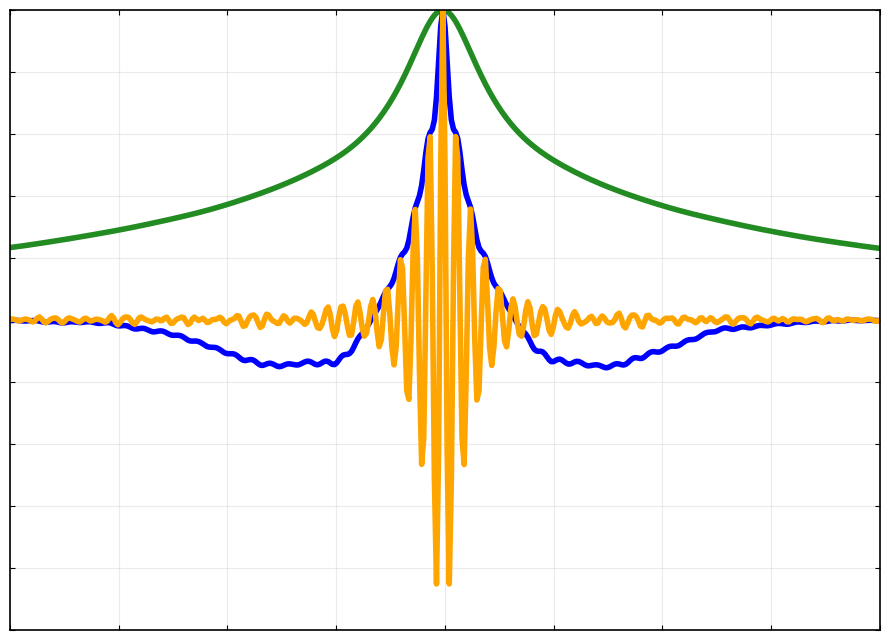

In [1]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

data = sio.loadmat("trace_paper_corr.mat")

x = data["x"].squeeze()
avg_filtered = data["avg_filtered"].squeeze()
avg_raw = data["avg_raw"].squeeze()
avg_spec = data["avg_spec"].squeeze()

# Plot
fig, ax = plt.subplots(figsize=(9, 6.5))

# spectrogram correlation - green
ax.plot(x,
    avg_spec,
    color="forestgreen",
    linewidth=4)

# filtered correlation - orange
ax.plot(x,
    avg_filtered,
    color=(240/255, 99/255, 8/255),
    linewidth=4)

# raw correlation - blue
ax.plot(x,
    avg_raw,
    color="blue",
    linewidth=4)

ax.set_xlim(-0.4, 0.4)
ax.set_ylim(-1, 1)


ax.set_xticks(np.arange(-0.4, 0.41, 0.1))
ax.set_yticks(np.arange(-1, 1.01, 0.2))

def clean_tick(x, pos):
    if abs(x) < 1e-10:
        return "0"
    return f"{x:g}"

ax.xaxis.set_major_formatter(FuncFormatter(clean_tick))
ax.yaxis.set_major_formatter(FuncFormatter(clean_tick))

ax.grid(True, alpha=0.25)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
    labelsize=16
)
ax.set_xticklabels([])
ax.set_yticklabels([])

for spine in ax.spines.values():
    spine.set_linewidth(1.2)


plt.tight_layout()
plt.show()
